# GNSS II Lab: From Daily Positions to Deformation Time Series

> **Colab note:** This notebook is designed to run on **Google Colab**. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS166/blob/main/notebooks/02_gnss_timeseries.ipynb)

## Introduction

GNSS position time series contain multiple signals superimposed on one another. In this lab, you will use station **ALBH** in southern Vancouver Island to determine how trend and seasonal terms affect an estimated velocity—and how removing those signals reveals slow slip.

## Learning objectives

By the end, you will be able to:

- interpret east, north, and up position components
- fit nested time-series models using least squares
- compare velocities estimated with different model terms
- use residuals to recognize a gradual transient
- test whether a candidate transient is coherent across nearby stations

## Notebook Outline:
- [Part I: Read a three-component timeseries](#part-i-read-a-three-component-time-series)
- [Part II: Build nested time-series models](#part-ii-build-nested-time-series-models)
- [Part III: Decompose all three components](#part-iii-decompose-all-three-components)
- [Part IV: Examine the 2015–2016 slow-slip event](#part-iv-examine-the-2015-2016-slow-slip-event)
- [Part V: Is the signal coherent across the network?](#part-v-is-the-signal-coherent-across-the-network)
- [Synthesis](#Synthesis)
- [Summary](#Summary)


## Setup

The notebook uses NumPy, pandas, xarray, Matplotlib, and the CRESCENT GNSS time-series dataset. Run this cell once before continuing.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import requests
from io import BytesIO

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:
url = "https://zenodo.org/records/20518159/files/gnss_SOPAC_trend_2010_2025.nc?download=1"

response = requests.get(url, timeout=120)
response.raise_for_status()
ds = xr.open_dataset(BytesIO(response.content), engine="h5netcdf")

print(f"Stations: {ds.sizes['station']}")
print(f"Dates: {pd.to_datetime(ds.time.values).min().date()} to "
      f"{pd.to_datetime(ds.time.values).max().date()}")


Stations: 340
Dates: 2010-01-01 to 2025-12-31


---

## Part I: Read a three-component time series

Daily positions are expressed relative to a reference position in local **east**, **north**, and **up** coordinates. Before fitting anything, inspect all three components.

### Prediction

Which component do you expect to have the most scatter and the largest seasonal signal? Why?


In [3]:
station = "albh"
stat = ds.sel(station=station)

df = pd.DataFrame({
    "time": pd.to_datetime(stat.time.values),
    "dec_year": stat.dec_year.values,
    "east_mm": 1000 * stat.east_m.values,
    "north_mm": 1000 * stat.north_m.values,
    "up_mm": 1000 * stat.up_m.values,
    "east_sig": 1000 * stat.east_sigma_m.values,
    "north_sig": 1000 * stat.north_sigma_m.values,
    "up_sig": 1000 * stat.up_sigma_m.values,
})

print(f"ALBH: {len(df):,} daily epochs")
df.head()


ALBH: 5,844 daily epochs


,time,dec_year,east_mm,north_mm,up_mm,east_sig,north_sig,up_sig
0,2010-01-01,2010.0014,-136.79,-137.65,13.17,2.12,1.53,4.90
1,2010-01-02,2010.0041,-137.49,-137.65,10.07,1.85,1.40,4.39
2,2010-01-03,2010.0068,-137.29,-136.65,3.87,1.72,1.40,4.26
3,2010-01-04,2010.0096,-137.99,-136.85,13.07,1.72,1.40,4.26
4,2010-01-05,2010.0123,-138.19,-136.65,13.47,1.99,1.40,4.51


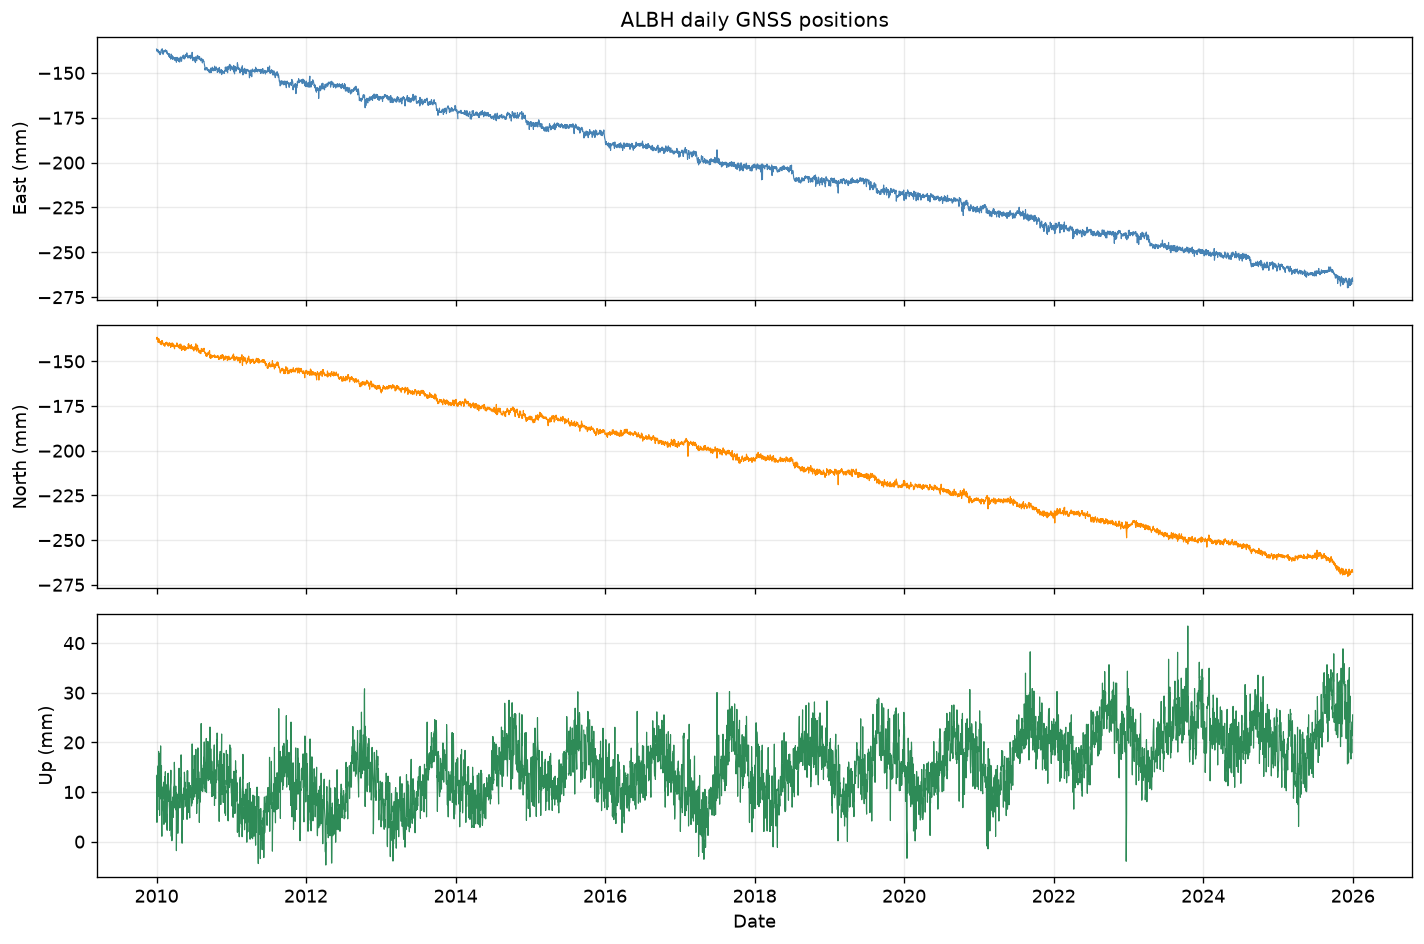

In [4]:
components = [
    ("east_mm", "East", "steelblue"),
    ("north_mm", "North", "darkorange"),
    ("up_mm", "Up", "seagreen"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, (column, label, color) in zip(axes, components):
    ax.plot(df.time, df[column], color=color, lw=0.7)
    ax.set_ylabel(f"{label} (mm)")

axes[0].set_title("ALBH daily GNSS positions")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


> **Interpret the observations:**
> 1. Which components have a clear long-term trend?
> 2. Where do you see seasonal variation?
> 3. Which component is noisiest?
> 4. Can you confidently identify slow-slip events in the raw record? Explain.


---

## Part II: Build nested time-series models

We will compare two models:

**Trend only**

$$y(t)=a+vt+\epsilon(t)$$

**Trend + annual + semiannual signals**

$$y(t)=a+vt+A_1\cos(2\pi t)+B_1\sin(2\pi t)+A_2\cos(4\pi t)+B_2\sin(4\pi t)+\epsilon(t)$$

Here, $t$ is measured in years and $v$ is velocity in mm/yr.


In [5]:
def build_design_matrix(time_years, seasonal=False):
    """
    Construct a design matrix for a linear GNSS time-series model.

    The model always includes an offset and a linear velocity. If
    ``seasonal=True``, annual and semiannual sine and cosine terms are
    also included. Time is centered on its mean to reduce covariance
    between the estimated offset and velocity.

    Parameters
    ----------
    time_years : array-like
        Observation times in decimal years.
    seasonal : bool, default=False
        If True, include annual and semiannual seasonal terms.

    Returns
    -------
    G : numpy.ndarray
        Design matrix with one row per observation and one column per
        model parameter.
    names : list of str
        Names of the model parameters in the same order as the columns
        of ``G``.
    """
    t0 = np.nanmean(time_years)
    t = time_years - t0

    columns = [np.ones(len(t)), t]
    names = ["offset", "velocity"]

    if seasonal:
        columns.extend([
            np.cos(2 * np.pi * time_years),
            np.sin(2 * np.pi * time_years),
            np.cos(4 * np.pi * time_years),
            np.sin(4 * np.pi * time_years),
        ])
        names.extend([
            "annual_cos",
            "annual_sin",
            "semiannual_cos",
            "semiannual_sin",
        ])

    return np.column_stack(columns), names


def fit_time_series(time_years, displacement_mm, sigma_mm, seasonal=False):
    """
    Fit a linear model to a GNSS displacement time series.

    The function estimates an offset and linear velocity using weighted
    least squares. Annual and semiannual terms can optionally be included.
    Observations with nonfinite values or nonpositive uncertainties are
    excluded from the fit.

    Parameters
    ----------
    time_years : array-like
        Observation times in decimal years.
    displacement_mm : array-like
        Observed displacements in millimeters.
    sigma_mm : array-like
        One-standard-deviation uncertainties for the displacement
        observations, in millimeters.
    seasonal : bool, default=False
        If True, fit annual and semiannual sine and cosine terms in
        addition to the offset and linear velocity.

    Returns
    -------
    result : dict
        Dictionary containing:

        ``parameters``
            Estimated model parameters.
        ``names``
            Parameter names corresponding to ``parameters``.
        ``prediction``
            Model-predicted displacement at every input time.
        ``residual``
            Observed displacement minus predicted displacement.
        ``valid``
            Boolean array indicating which observations were included
            in the fit.
    """
    valid = (
        np.isfinite(time_years)
        & np.isfinite(displacement_mm)
        & np.isfinite(sigma_mm)
        & (sigma_mm > 0)
    )

    G, names = build_design_matrix(
        time_years[valid],
        seasonal=seasonal,
    )

    # Apply the observational weights without constructing a diagonal matrix.
    A = G / sigma_mm[valid, None]
    b = displacement_mm[valid] / sigma_mm[valid]

    parameters, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

    G_all, _ = build_design_matrix(
        time_years,
        seasonal=seasonal,
    )

    prediction = G_all @ parameters
    residual = displacement_mm - prediction

    return {
        "parameters": parameters,
        "names": names,
        "prediction": prediction,
        "residual": residual,
        "valid": valid,
    }

### Prediction 2

The ALBH record spans many complete years. Do you expect adding seasonal terms to change the east-component velocity substantially, slightly, or not at all? Record your prediction.


In [6]:
t = df.dec_year.to_numpy()
d = df.east_mm.to_numpy()
sigma = df.east_sig.to_numpy()

trend_fit = fit_time_series(t, d, sigma, seasonal=False)
seasonal_fit = fit_time_series(t, d, sigma, seasonal=True)

velocity_trend = trend_fit["parameters"][1]
velocity_seasonal = seasonal_fit["parameters"][1]

print(f"Trend-only velocity:       {velocity_trend:+.3f} mm/yr")
print(f"Trend + seasonal velocity: {velocity_seasonal:+.3f} mm/yr")
print(f"Difference:                {velocity_seasonal - velocity_trend:+.3f} mm/yr")


Trend-only velocity:       -7.885 mm/yr
Trend + seasonal velocity: -7.883 mm/yr
Difference:                +0.002 mm/yr


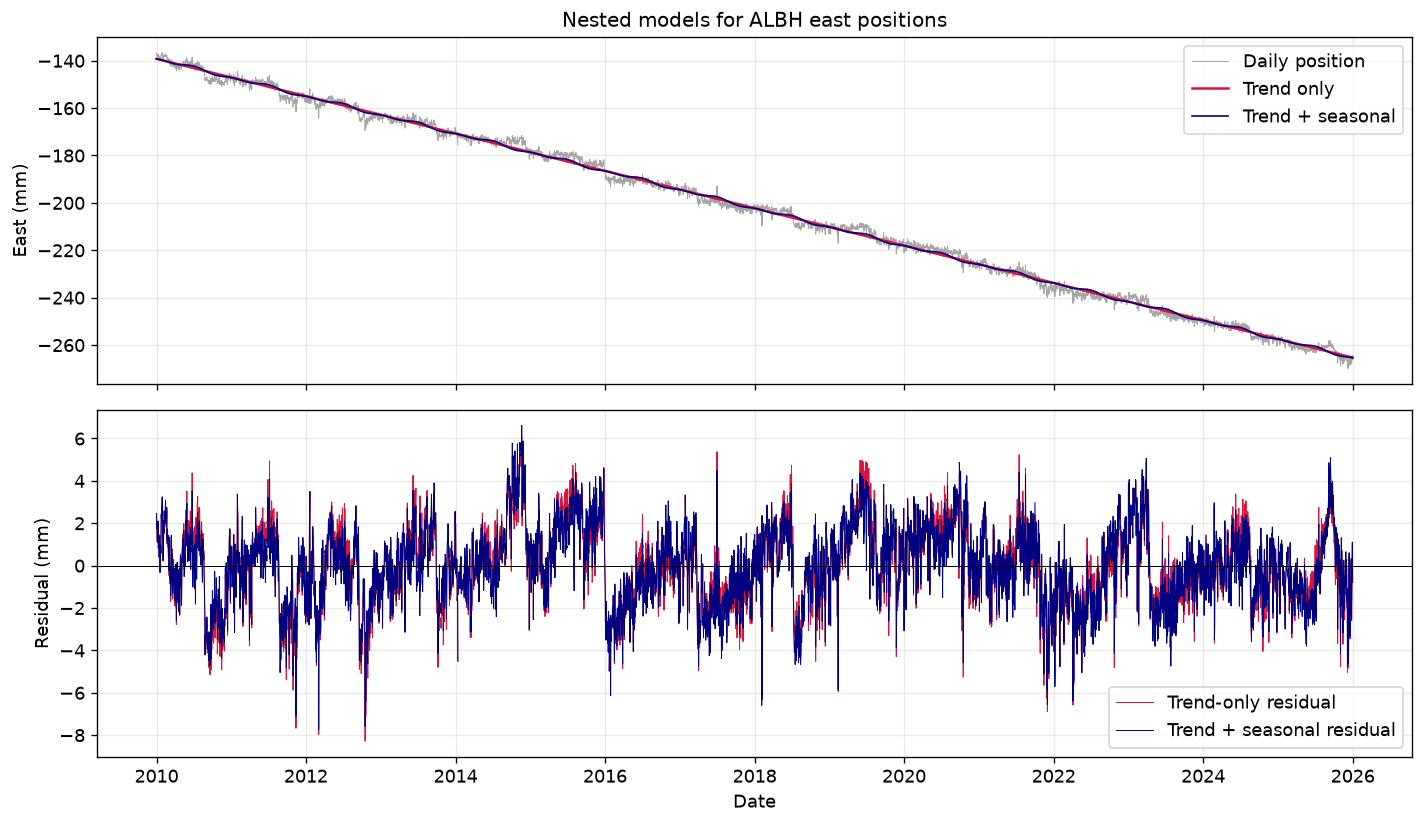

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df.time, d, color="0.65", lw=0.6, label="Daily position")
axes[0].plot(df.time, trend_fit["prediction"], color="crimson", lw=1.5,
             label="Trend only")
axes[0].plot(df.time, seasonal_fit["prediction"], color="navy", lw=1.0,
             label="Trend + seasonal")
axes[0].set_ylabel("East (mm)")
axes[0].set_title("Nested models for ALBH east positions")
axes[0].legend()

axes[1].plot(df.time, trend_fit["residual"], color="crimson", lw=0.6,
             label="Trend-only residual")
axes[1].plot(df.time, seasonal_fit["residual"], color="navy", lw=0.6,
             label="Trend + seasonal residual")
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_ylabel("Residual (mm)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()


> **Compare the models:**
> 1. How much did the estimated velocity change?
> 2. Which residual series retains an annual oscillation?
> 3. Does a small change in velocity mean seasonal terms are unnecessary? Why or why not?
> 4. Why might the effect be larger for a shorter record?


---

## Part III: Decompose all three components

Fit the trend-plus-seasonal model to east, north, and up. The residual is what remains after these specified terms are removed; it can contain deformation not represented by the model, outliers, and correlated noise.


In [8]:
fits = {}
for column, label, color in components:
    sigma_column = column.replace("_mm", "_sig")
    fits[column] = fit_time_series(
        df.dec_year.to_numpy(),
        df[column].to_numpy(),
        df[sigma_column].to_numpy(),
        seasonal=True,
    )
    print(f"{label:5s}: {fits[column]['parameters'][1]:+7.3f} mm/yr")


East :  -7.883 mm/yr
North:  -7.806 mm/yr
Up   :  +0.859 mm/yr


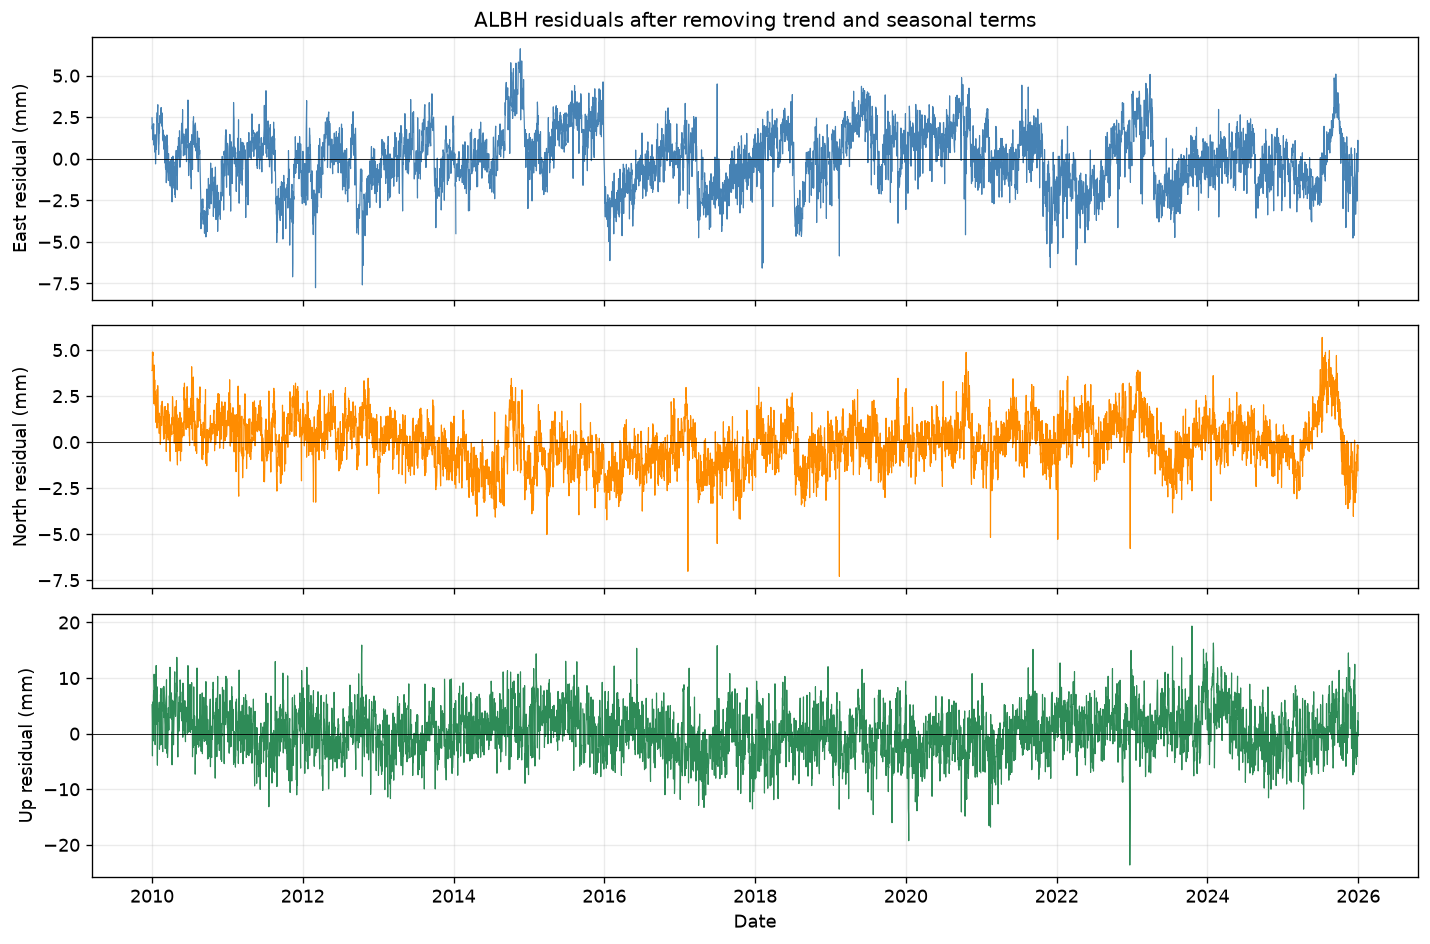

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, (column, label, color) in zip(axes, components):
    ax.plot(df.time, fits[column]["residual"], color=color, lw=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel(f"{label} residual (mm)")

axes[0].set_title("ALBH residuals after removing trend and seasonal terms")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


> **Read the residuals:**
> 1. What structure remains after removing the trend and seasonal model?
> 2. Do the east and north residuals contain signals that evolve over days to weeks?
> 3. Identify one outlier, gap, or possible offset.
> 4. Why should a residual not automatically be interpreted as tectonic deformation?


---

## Part IV: Examine the 2015–2016 slow-slip event

Slow slip produces gradual displacement over days to weeks, not a one-day step. We will zoom in on a documented Cascadia event and compare residual positions before and after it.


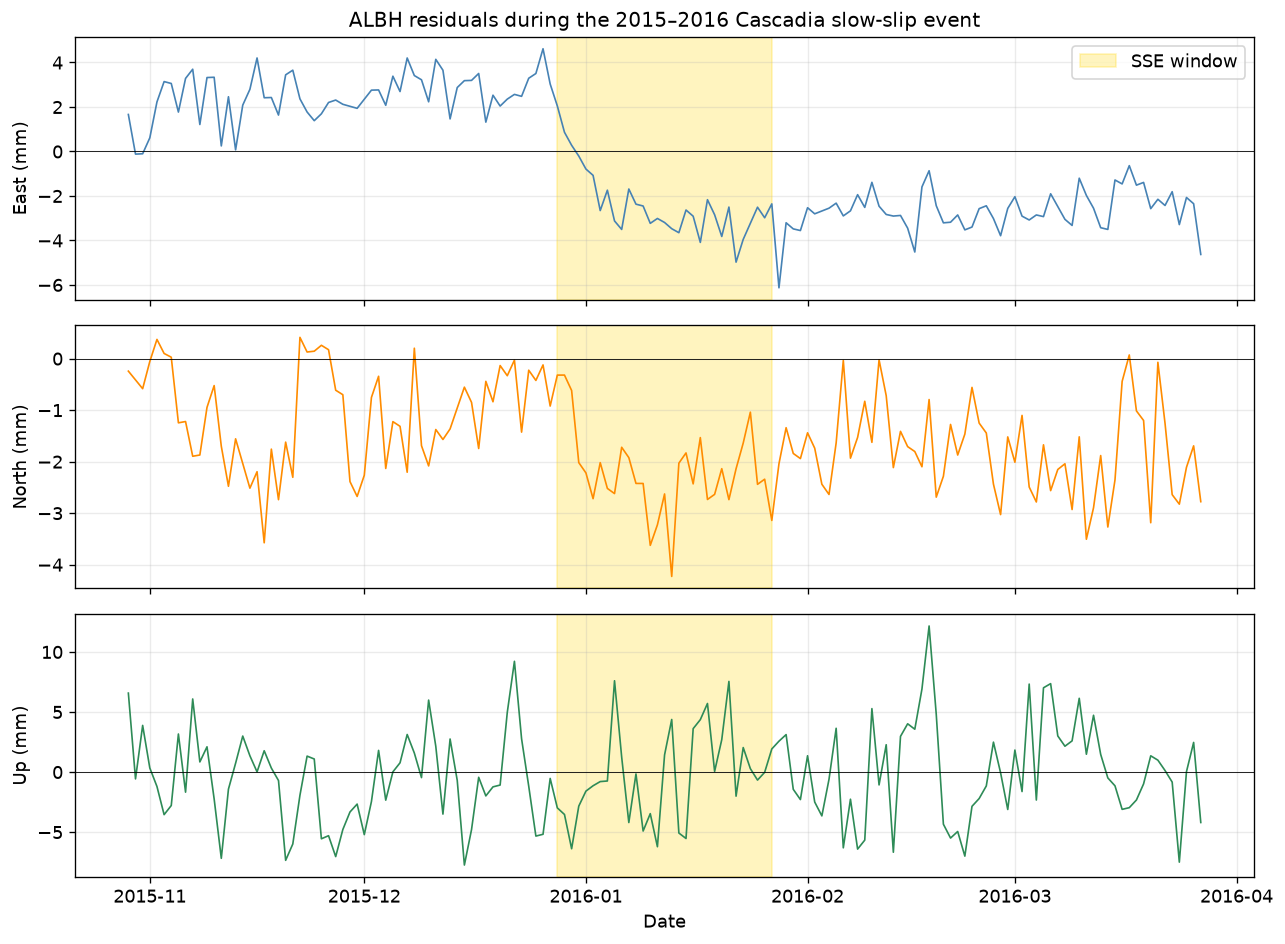

In [10]:
event_start = pd.Timestamp("2015-12-28")
event_end = pd.Timestamp("2016-01-27")
plot_start = event_start - pd.Timedelta(days=60)
plot_end = event_end + pd.Timedelta(days=60)

window = df.time.between(plot_start, plot_end)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, (column, label, color) in zip(axes, components):
    residual = fits[column]["residual"]
    ax.plot(df.loc[window, "time"], residual[window], color=color, lw=1.0)
    ax.axvspan(event_start, event_end, color="gold", alpha=0.25, label="SSE window")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel(f"{label} (mm)")

axes[0].set_title("ALBH residuals during the 2015–2016 Cascadia slow-slip event")
axes[0].legend()
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


### Estimate the net displacement

Use 14-day means before and after the event as a simple displacement estimate. This is not a full slow-slip model: the answer depends on the selected windows and on any remaining trend or noise.


In [11]:
window_days = 14  # Change this value and rerun the cell.

pre = df.time.between(event_start - pd.Timedelta(days=window_days), event_start)
post = df.time.between(event_end, event_end + pd.Timedelta(days=window_days))

offsets = {}
for column, label, color in components:
    residual = pd.Series(fits[column]["residual"], index=df.index)
    offsets[label] = residual[post].mean() - residual[pre].mean()
    print(f"{label:5s} displacement: {offsets[label]:+6.2f} mm")

horizontal = np.hypot(offsets["East"], offsets["North"])
print(f"Horizontal magnitude: {horizontal:.2f} mm")


East  displacement:  -5.71 mm
North displacement:  -1.12 mm
Up    displacement:  +0.20 mm
Horizontal magnitude: 5.82 mm


> **Test the estimate:**
> 1. Is the displacement instantaneous or accumulated through the shaded interval?
> 2. Change `window_days` to 7 and 28. How stable is the estimate?
> 3. In which horizontal direction did ALBH move?
> 4. What additional modeling would improve this estimate?


---

## Part V: Is the signal coherent across the network?

A tectonic transient should generally appear coherently at multiple stations, with amplitudes and directions that vary spatially. This comparison also helps distinguish regional deformation from a problem at one monument.


In [12]:
def distance_km(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distances between geographic coordinates.

    Uses the haversine formula to calculate the distance from one
    location to one or more other locations.

    Parameters
    ----------
    lat1, lon1 : float
        Latitude and longitude of the reference location, in degrees.
    lat2, lon2 : float or array-like
        Latitude and longitude of the comparison locations, in degrees.

    Returns
    -------
    float or numpy.ndarray
        Great-circle distance or distances in kilometers.
    """
    radius = 6371.0  # Mean radius of Earth in kilometers

    p1 = np.radians(lat1)
    p2 = np.radians(lat2)

    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)

    a = (
        np.sin(dp / 2) ** 2
        + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    )

    return 2 * radius * np.arcsin(np.sqrt(a))


target_lat = float(stat.lat.values)
target_lon = float(stat.lon.values)
distances = distance_km(target_lat, target_lon, ds.lat.values, ds.lon.values)
nearest = np.argsort(distances)[:5]
nearby_stations = ds.station.values[nearest]

print("Nearest stations:", ", ".join(map(str, nearby_stations)))


Nearest stations: albh, pgc5, ptaa, p435, sc02


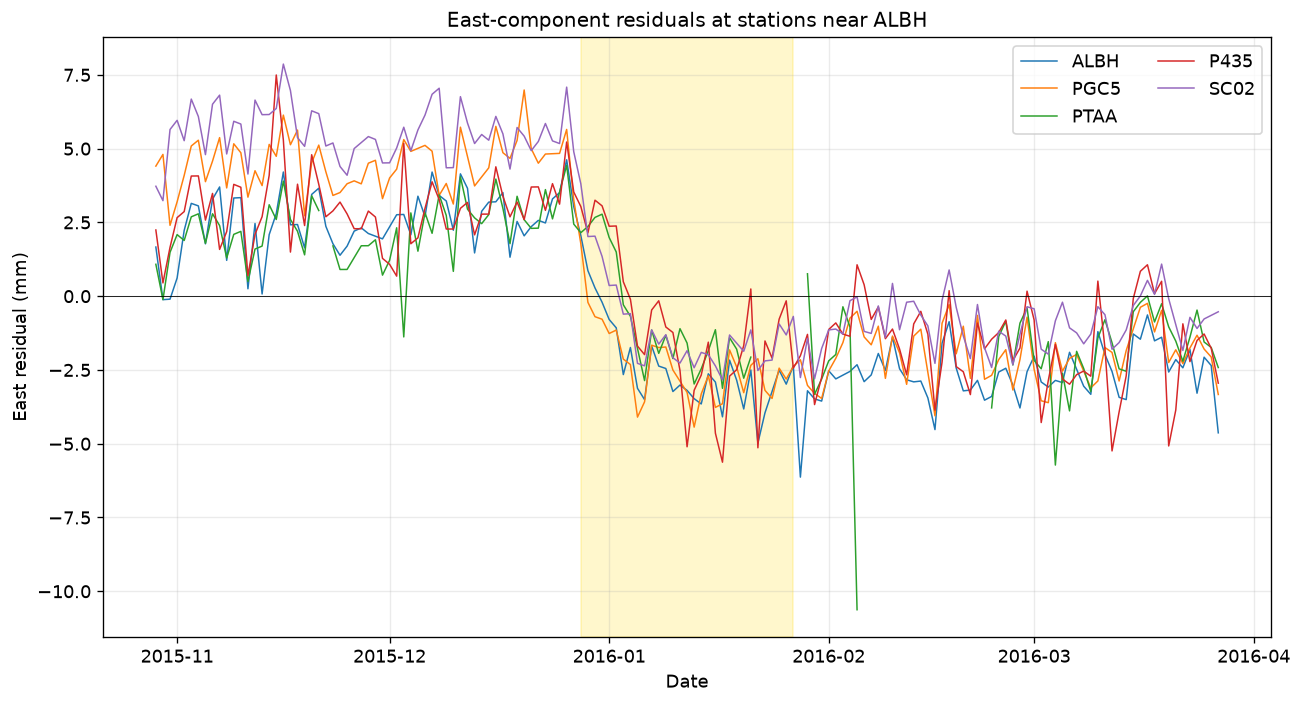

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))

for station_name in nearby_stations:
    station_data = ds.sel(station=station_name)
    time = pd.to_datetime(station_data.time.values)
    years = station_data.dec_year.values
    east = 1000 * station_data.east_m.values
    east_sigma = 1000 * station_data.east_sigma_m.values
    fit = fit_time_series(years, east, east_sigma, seasonal=True)
    use = (time >= plot_start) & (time <= plot_end)
    ax.plot(time[use], fit["residual"][use], lw=0.9, label=str(station_name).upper())

ax.axvspan(event_start, event_end, color="gold", alpha=0.2)
ax.axhline(0, color="black", lw=0.5)
ax.set(title="East-component residuals at stations near ALBH",
       xlabel="Date", ylabel="East residual (mm)")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


> **Interpret the network:**
> 1. Is the transient visible at more than one station?
> 2. Are its amplitude and detailed shape identical everywhere?
> 3. What would a signal present with nearly identical amplitude at every station suggest?
> 4. What evidence supports interpreting this event as regional deformation rather than an ALBH equipment problem?

---

## Synthesis

> **Answer each question in one or two sentences:**
> 1. Why can omitted seasonal terms bias velocity, especially in a short record?
> 2. What does the residual contain after trend and seasonal terms are removed?
> 3. How does a slow-slip event differ from a coseismic offset in a daily time series?
> 4. Why is network coherence important when interpreting a transient?
> 5. Which result in this notebook is expressed in a reference frame, even though we did not transform frames ourselves?


---

## Summary

- Daily east, north, and up positions combine tectonic signals, seasonal motion, offsets, transients, and noise.
- Nested models show how the choice of model terms affects velocity and residual structure.
- Removing a justified trend and seasonal model makes the ALBH slow-slip signal easier to recognize.
- A gradual transient should be evaluated using its duration, station metadata, and coherence across a network.
- Formal daily uncertainties do not capture all temporally correlated noise in the residuals.

### Data source

CRESCENT GNSS time-series compilation distributed through Zenodo. Record the selected provider, processing version, reference frame, and access date when using these data in an analysis.
